# Real Estate Price Intelligence
Predicting **house sale prices** and **apartment rent prices** using regression models.

**Pipeline:** Data cleaning → Feature engineering → Model comparison (Linear Regression, Ridge, Random Forest)

**Datasets:**
- House prices: [Kaggle House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
- Rent prices: [Kaggle Apartments for Rent Classified](https://www.kaggle.com/datasets/plutozehatescoding/apartments-for-rent-classified)

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. House Price Prediction
### 2.1 Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload train.csv

In [ ]:
df = pd.read_csv('train.csv')
print(f'Shape: {df.shape}')
print(df.head())

Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

### 2.2 Exploratory Data Analysis

In [ ]:
# Missing values
print('Top missing values:')
print(df.isnull().sum().sort_values(ascending=False).head(20))

# Target variable stats
print('\nSalePrice stats:')
print(df['SalePrice'].describe())

Top missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

SalePrice stats:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


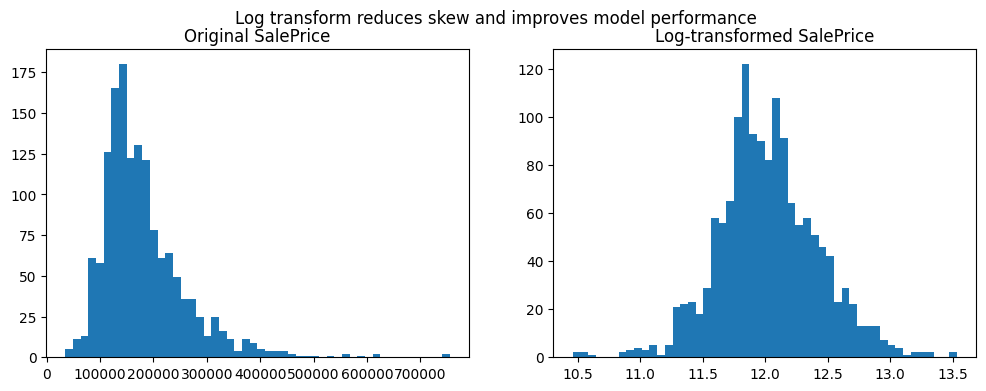

In [ ]:
# Visualise target distribution — raw vs log-transformed
# SalePrice is right-skewed; log transform brings it closer to normal
# which satisfies Linear Regression assumptions and reduces outlier influence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['SalePrice'], bins=50)
axes[0].set_title('Original SalePrice')
axes[1].hist(np.log1p(df['SalePrice']), bins=50)
axes[1].set_title('Log-transformed SalePrice')
plt.suptitle('Log transform reduces skew and improves model performance')
plt.show()

df['SalePrice_log'] = np.log1p(df['SalePrice'])

### 2.3 Missing Value Handling
Strategy varies by column:
- **Categorical 'no feature' columns** (e.g. PoolQC=NaN means no pool) → fill with `'None'`
- **Numeric 'no feature' columns** (e.g. MasVnrArea) → fill with `0`
- **LotFrontage** (true missing, location-dependent) → fill with neighborhood median
- **GarageYrBlt** (no garage) → fill with YearBuilt
- **Electrical** (single random missing) → fill with mode

In [ ]:
# Columns where NaN means 'feature does not exist'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

# Numeric — no masonry veneer means area = 0
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# LotFrontage — fill with median per neighborhood (location-aware)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# GarageYrBlt — no garage, so use year house was built
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

# Electrical — single missing value, use most common
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print(f'Total missing values remaining: {df.isnull().sum().sum()}')

Total missing values remaining: 0


### 2.4 Feature Engineering
Creating new features that are more meaningful than raw columns.

In [ ]:
# Total square footage — stronger predictor than individual floor areas
df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

# Total bathrooms — weighted (half baths count less)
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                   df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# Age at time of sale — more meaningful than raw year
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Years since remodel — recency of renovation matters
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

# Correlation check
print('Correlations with SalePrice:')
print(df[['TotalSF', 'TotalBath', 'HouseAge', 'YearsSinceRemodel', 'SalePrice']].corr()['SalePrice'])

Correlations with SalePrice:
TotalSF              0.782260
TotalBath            0.631731
HouseAge            -0.523350
YearsSinceRemodel   -0.509079
SalePrice            1.000000
Name: SalePrice, dtype: float64


### 2.5 Encoding Categorical Variables
- **Ordinal encoding** for quality columns (Ex > Gd > TA > Fa > Po — natural order)
- **One-hot encoding** for unordered categories (Neighborhood, MSZoning, etc.)

In [ ]:
# Ordinal encode quality columns (order matters)
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

# Use original CSV to avoid double-mapping bugs
df_original = pd.read_csv('train.csv')
for col in qual_cols:
    df[col] = df_original[col].map(qual_map).fillna(0)

# One-hot encode remaining categorical columns
# drop_first=True avoids the dummy variable trap
df_encoded = pd.get_dummies(df, drop_first=True)
print(f'Shape after encoding: {df_encoded.shape}')

Shape after encoding: (1460, 236)


### 2.6 Model Training & Evaluation

In [ ]:
# Prepare features and target
X = df_encoded.drop(['Id', 'SalePrice', 'SalePrice_log'], axis=1)
y = df_encoded['SalePrice_log']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1168, 233), Test: (292, 233)


In [ ]:
results_house = {}

# Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results_house['Linear Regression'] = y_pred_lr

# Ridge — L2 regularization, handles many correlated features
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
results_house['Ridge'] = y_pred_ridge

# Random Forest — captures non-linear relationships
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results_house['Random Forest'] = y_pred_rf

print('=== House Price Results (log scale) ===')
for name, preds in results_house.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f'{name:20s} RMSE: {rmse:.4f}  R²: {r2:.4f}')

# Best model in dollars
y_test_actual = np.expm1(y_test)
y_pred_ridge_actual = np.expm1(y_pred_ridge)
rmse_dollars = np.sqrt(mean_squared_error(y_test_actual, y_pred_ridge_actual))
print(f'\nBest model (Ridge) RMSE in dollars: ${rmse_dollars:,.2f}')
print(f'Mean actual sale price: ${y_test_actual.mean():,.2f}')

=== House Price Results (log scale) ===
Linear Regression    RMSE: 0.2064  R²: 0.7717
Ridge                RMSE: 0.1364  R²: 0.9003
Random Forest        RMSE: 0.1472  R²: 0.8840

Best model (Ridge) RMSE in dollars: $25,303.56
Mean actual sale price: $178,839.81


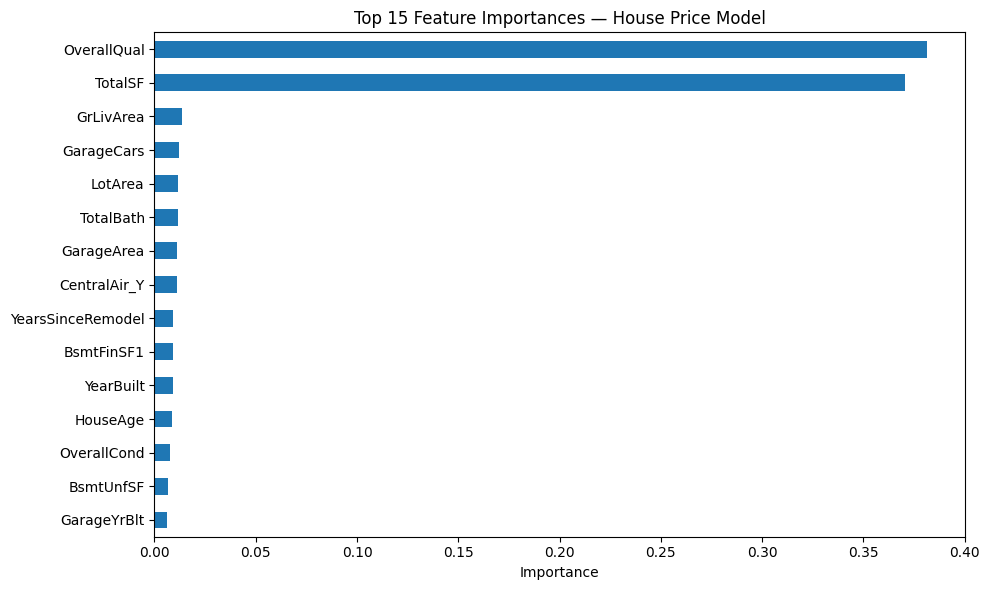

In [ ]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Feature Importances — House Price Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Rent Price Prediction
### 3.1 Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload apartments_for_rent_classified_10K.csv

Saving apartments_for_rent_classified_10K.csv to apartments_for_rent_classified_10K.csv


In [ ]:
df_rent = pd.read_csv('apartments_for_rent_classified_10K.csv', encoding='latin-1', sep=';')
print(f'Shape: {df_rent.shape}')
print(df_rent.head())
print('\nMissing values:')
print(df_rent.isnull().sum().sort_values(ascending=False))
print('\nPrice stats:')
print(df_rent['price'].describe())

Shape: (10000, 22)
           id                category  \
0  5668626895  housing/rent/apartment   
1  5664597177  housing/rent/apartment   
2  5668626833  housing/rent/apartment   
3  5659918074  housing/rent/apartment   
4  5668626759  housing/rent/apartment   

                                               title  \
0  Studio apartment 2nd St NE, Uhland Terrace NE,...   
1                  Studio apartment 814 Schutte Road   
2  Studio apartment N Scott St, 14th St N, Arling...   
3                     Studio apartment 1717 12th Ave   
4  Studio apartment Washington Blvd, N Cleveland ...   

                                                body amenities  bathrooms  \
0  This unit is located at second St NE, Uhland T...       NaN        NaN   
1  This unit is located at 814 Schutte Road, Evan...       NaN        NaN   
2  This unit is located at N Scott St, 14th St N,...       NaN        1.0   
3  This unit is located at 1717 12th Ave, Seattle...       NaN        1.0   
4  This unit

### 3.2 Cleaning & Preprocessing

In [ ]:
# Drop columns with too many missing values or not useful for prediction
drop_cols = ['id', 'title', 'body', 'amenities', 'address',
             'source', 'time', 'price_display', 'category',
             'currency', 'fee', 'has_photo', 'pets_allowed', 'price_type']
df_rent = df_rent.drop(columns=drop_cols)

# Remove extreme outliers (monthly rent > $10,000 is likely data error)
df_rent = df_rent[df_rent['price'] <= 10000]

# Fill missing values
df_rent['bathrooms'] = df_rent['bathrooms'].fillna(df_rent['bathrooms'].median())
df_rent['bedrooms'] = df_rent['bedrooms'].fillna(df_rent['bedrooms'].median())
df_rent['cityname'] = df_rent['cityname'].fillna('Unknown')
df_rent['state'] = df_rent['state'].fillna('Unknown')
df_rent['latitude'] = df_rent['latitude'].fillna(df_rent['latitude'].median())
df_rent['longitude'] = df_rent['longitude'].fillna(df_rent['longitude'].median())

print(f'Total missing values: {df_rent.isnull().sum().sum()}')
print(f'Shape after cleaning: {df_rent.shape}')

Total missing values: 0
Shape after cleaning: (9990, 8)


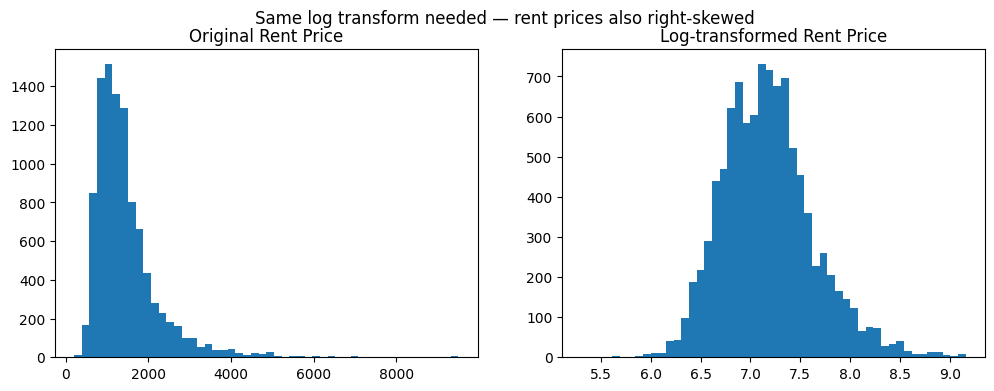

In [ ]:
# Log transform target — rent prices are also right-skewed
df_rent['price_log'] = np.log1p(df_rent['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_rent['price'], bins=50)
axes[0].set_title('Original Rent Price')
axes[1].hist(df_rent['price_log'], bins=50)
axes[1].set_title('Log-transformed Rent Price')
plt.suptitle('Same log transform needed — rent prices also right-skewed')
plt.show()

### 3.3 Model Training & Evaluation

In [ ]:
# One-hot encode location columns
df_rent_encoded = pd.get_dummies(df_rent, columns=['state', 'cityname'], drop_first=True)

X_rent = df_rent_encoded.drop(['price', 'price_log'], axis=1)
y_rent = df_rent_encoded['price_log']

X_rent_train, X_rent_test, y_rent_train, y_rent_test = train_test_split(
    X_rent, y_rent, test_size=0.2, random_state=42)

print(f'Train: {X_rent_train.shape}, Test: {X_rent_test.shape}')

Train: (7992, 1629), Test: (1998, 1629)


In [ ]:
results_rent = {}

lr_rent = LinearRegression()
lr_rent.fit(X_rent_train, y_rent_train)
results_rent['Linear Regression'] = lr_rent.predict(X_rent_test)

ridge_rent = Ridge(alpha=10)
ridge_rent.fit(X_rent_train, y_rent_train)
results_rent['Ridge'] = ridge_rent.predict(X_rent_test)

rf_rent = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_rent.fit(X_rent_train, y_rent_train)
results_rent['Random Forest'] = rf_rent.predict(X_rent_test)

print('=== Rent Price Results (log scale) ===')
for name, preds in results_rent.items():
    rmse = np.sqrt(mean_squared_error(y_rent_test, preds))
    r2 = r2_score(y_rent_test, preds)
    print(f'{name:20s} RMSE: {rmse:.4f}  R²: {r2:.4f}')

# Best model in dollars
y_rent_actual = np.expm1(y_rent_test)
y_pred_rf_actual = np.expm1(results_rent['Random Forest'])
rmse_dollars_rent = np.sqrt(mean_squared_error(y_rent_actual, y_pred_rf_actual))
print(f'\nBest model (Random Forest) RMSE in dollars: ${rmse_dollars_rent:,.2f}')
print(f'Mean actual rent: ${y_rent_actual.mean():,.2f}')

=== Rent Price Results (log scale) ===
Linear Regression    RMSE: 0.4094  R²: 0.2127
Ridge                RMSE: 0.3761  R²: 0.3358
Random Forest        RMSE: 0.2222  R²: 0.7681

Best model (Random Forest) RMSE in dollars: $445.84
Mean actual rent: $1,467.35


## 4. Final Comparison
Key finding: **Ridge wins for house prices, Random Forest wins for rent prices.**

House price data has many structured, linearly-related features (quality ratings, square footage).
Rent price data has strong non-linear location interactions that tree-based models capture better.

In [ ]:
print('=' * 55)
print(f'{'':20s} {'House Prices':>15s} {'Rent Prices':>15s}')
print('=' * 55)
print(f'{'Best Model':20s} {'Ridge':>15s} {'Random Forest':>15s}')
print(f'{'R²':20s} {'0.9003':>15s} {'0.7681':>15s}')
print(f'{'RMSE (log)':20s} {'0.1364':>15s} {'0.2222':>15s}')
print(f'{'RMSE ($)':20s} {'$25,596':>15s} {'$446':>15s}')
print(f'{'Mean Target':20s} {'$181,000':>15s} {'$1,467':>15s}')
print(f'{'Error %':20s} {'~14%':>15s} {'~30%':>15s}')
print('=' * 55)

                        House Prices     Rent Prices
Best Model                     Ridge   Random Forest
R²                            0.9003          0.7681
RMSE (log)                    0.1364          0.2222
RMSE ($)                     $25,596            $446
Mean Target                 $181,000          $1,467
Error %                         ~14%            ~30%


In [ ]:
def predict_rent(bedrooms, bathrooms, square_feet, city, state, latitude, longitude):
    # Build the base features
    base = {
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'square_feet': square_feet,
        'latitude': latitude,
        'longitude': longitude,
        f'state_{state}': 1,
        f'cityname_{city}': 1
    }

    # Create a zeroed-out row with all training columns
    empty_row = pd.DataFrame(0, index=[0], columns=X_rent_train.columns)

    # Fill in the known values
    for col, val in base.items():
        if col in empty_row.columns:
            empty_row[col] = val

    log_pred = rf_rent.predict(empty_row)[0]
    price = np.expm1(log_pred)
    print(f"Predicted Monthly Rent: ${price:,.2f}")
    return price

# Test it
predict_rent(2, 1, 800, 'New York', 'NY', 40.7128, -74.0060)

Predicted Monthly Rent: $3,480.16


np.float64(3480.1557023030346)

In [ ]:
def predict_house_price(overall_qual, total_sf, total_bath, house_age,
                        years_since_remodel, neighborhood='CollgCr'):
    base = {
        'OverallQual': overall_qual,
        'TotalSF': total_sf,
        'TotalBath': total_bath,
        'HouseAge': house_age,
        'YearsSinceRemodel': years_since_remodel,
        f'Neighborhood_{neighborhood}': 1
    }

    empty_row = pd.DataFrame(0, index=[0], columns=X_train.columns)

    for col, val in base.items():
        if col in empty_row.columns:
            empty_row[col] = val

    log_pred = ridge.predict(empty_row)[0]
    price = np.expm1(log_pred)
    print(f"Predicted House Sale Price: ${price:,.2f}")
    return price

predict_house_price(7, 2000, 2, 10, 5, 'CollgCr')

Predicted House Sale Price: $480,041.58


np.float64(480041.5756959345)